# 01 · Physical reconstruction of the daily inundation and its checks

Paper 3 of the Kakhovka series. This notebook reads committed tables only.

**Reading rules.** Every model number is *agreement with weak reference labels*, never flood-mapping accuracy. "Not observed is not dry." Areas carry their semantics (observed_S1 / mapped_UNet / terrain_reconstructed / literature_reported). Evidence levels: independent_physical › cross_sensor › weak_label_agreement › contextual.

In [1]:
from pathlib import Path
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "case_studies/kakhovka_2023/tables").exists())
CS = ROOT / "case_studies/kakhovka_2023"; T = CS / "tables"; PT = CS / "publication/tables"; PF = CS / "publication/figures"; RUNS = CS / "runs"
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)
C = {"terrain": "#2a78d6", "s1": "#eb6834", "unet": "#4a3aa7", "rf": "#1baf7a", "gauge": "#52514e"}
def show(tid, n=None):
    df = pd.read_csv(PT / f"{tid}.csv"); cap = json.loads((PT / "manifest.json").read_text())["tables"][tid]
    display(Markdown(f"**{tid}** [{cap['evidence_level']}] {cap['caption']}")); return df.head(n) if n else df
def fig(name): p = next(PF.glob(name + "*.png"), None); display(Image(str(p), width=900)) if p else print("figure not rendered yet:", name)
print("repo:", ROOT)

repo: /home/niko/repo/floodstate-eo


## 1. The water surface
SWOT node heights (EGG2015-referenced, gauge-anchored with the Kherson-local closure of Paper 1) and the Kherson gauge; node-based interpolation (no chainage).

In [2]:
show('T11')

**T11** [independent_physical] Terrain reconstruction: rules, closure, constants and the water-surface method per variant. The superseded closure row is kept for traceability.

,variant,suffix,rule,closure,closure_offset_vs_p59_m,margin_m,river_floor_m,swot_max_dist_m,dist_to_prewater_max_m,baseline_until,wse_method,status
0,hand_and_ceiling,(default),hand_and_ceiling,kherson_paper1,0.2086,0.0,1.0,15000.0,10000.0,2023-06-05,node-based: median of K=5 nearest SWOT nodes w...,current
1,ceiling_only,_ceiling_only,ceiling_only,kherson_paper1,0.2086,0.0,1.0,15000.0,10000.0,2023-06-05,node-based: median of K=5 nearest SWOT nodes w...,current
2,connected_ceiling,_connected_ceiling,connected_ceiling,kherson_paper1,0.2086,0.0,1.0,15000.0,10000.0,2023-06-05,node-based: median of K=5 nearest SWOT nodes w...,current
3,connected_ceiling_dem_uncorrected,_connected_ceiling_dem_uncorrected,connected_ceiling,kherson_paper1,0.2086,0.0,1.0,15000.0,10000.0,2023-06-05,node-based: median of K=5 nearest SWOT nodes w...,current
4,"connected_ceiling (superseded closure, +0.5 m)",_connected_ceiling_closure_p59_m050,connected_ceiling,p59_reservoir,0.0000,0.5,1.0,15000.0,10000.0,2023-06-05,node-based: median of K=5 nearest SWOT nodes w...,superseded


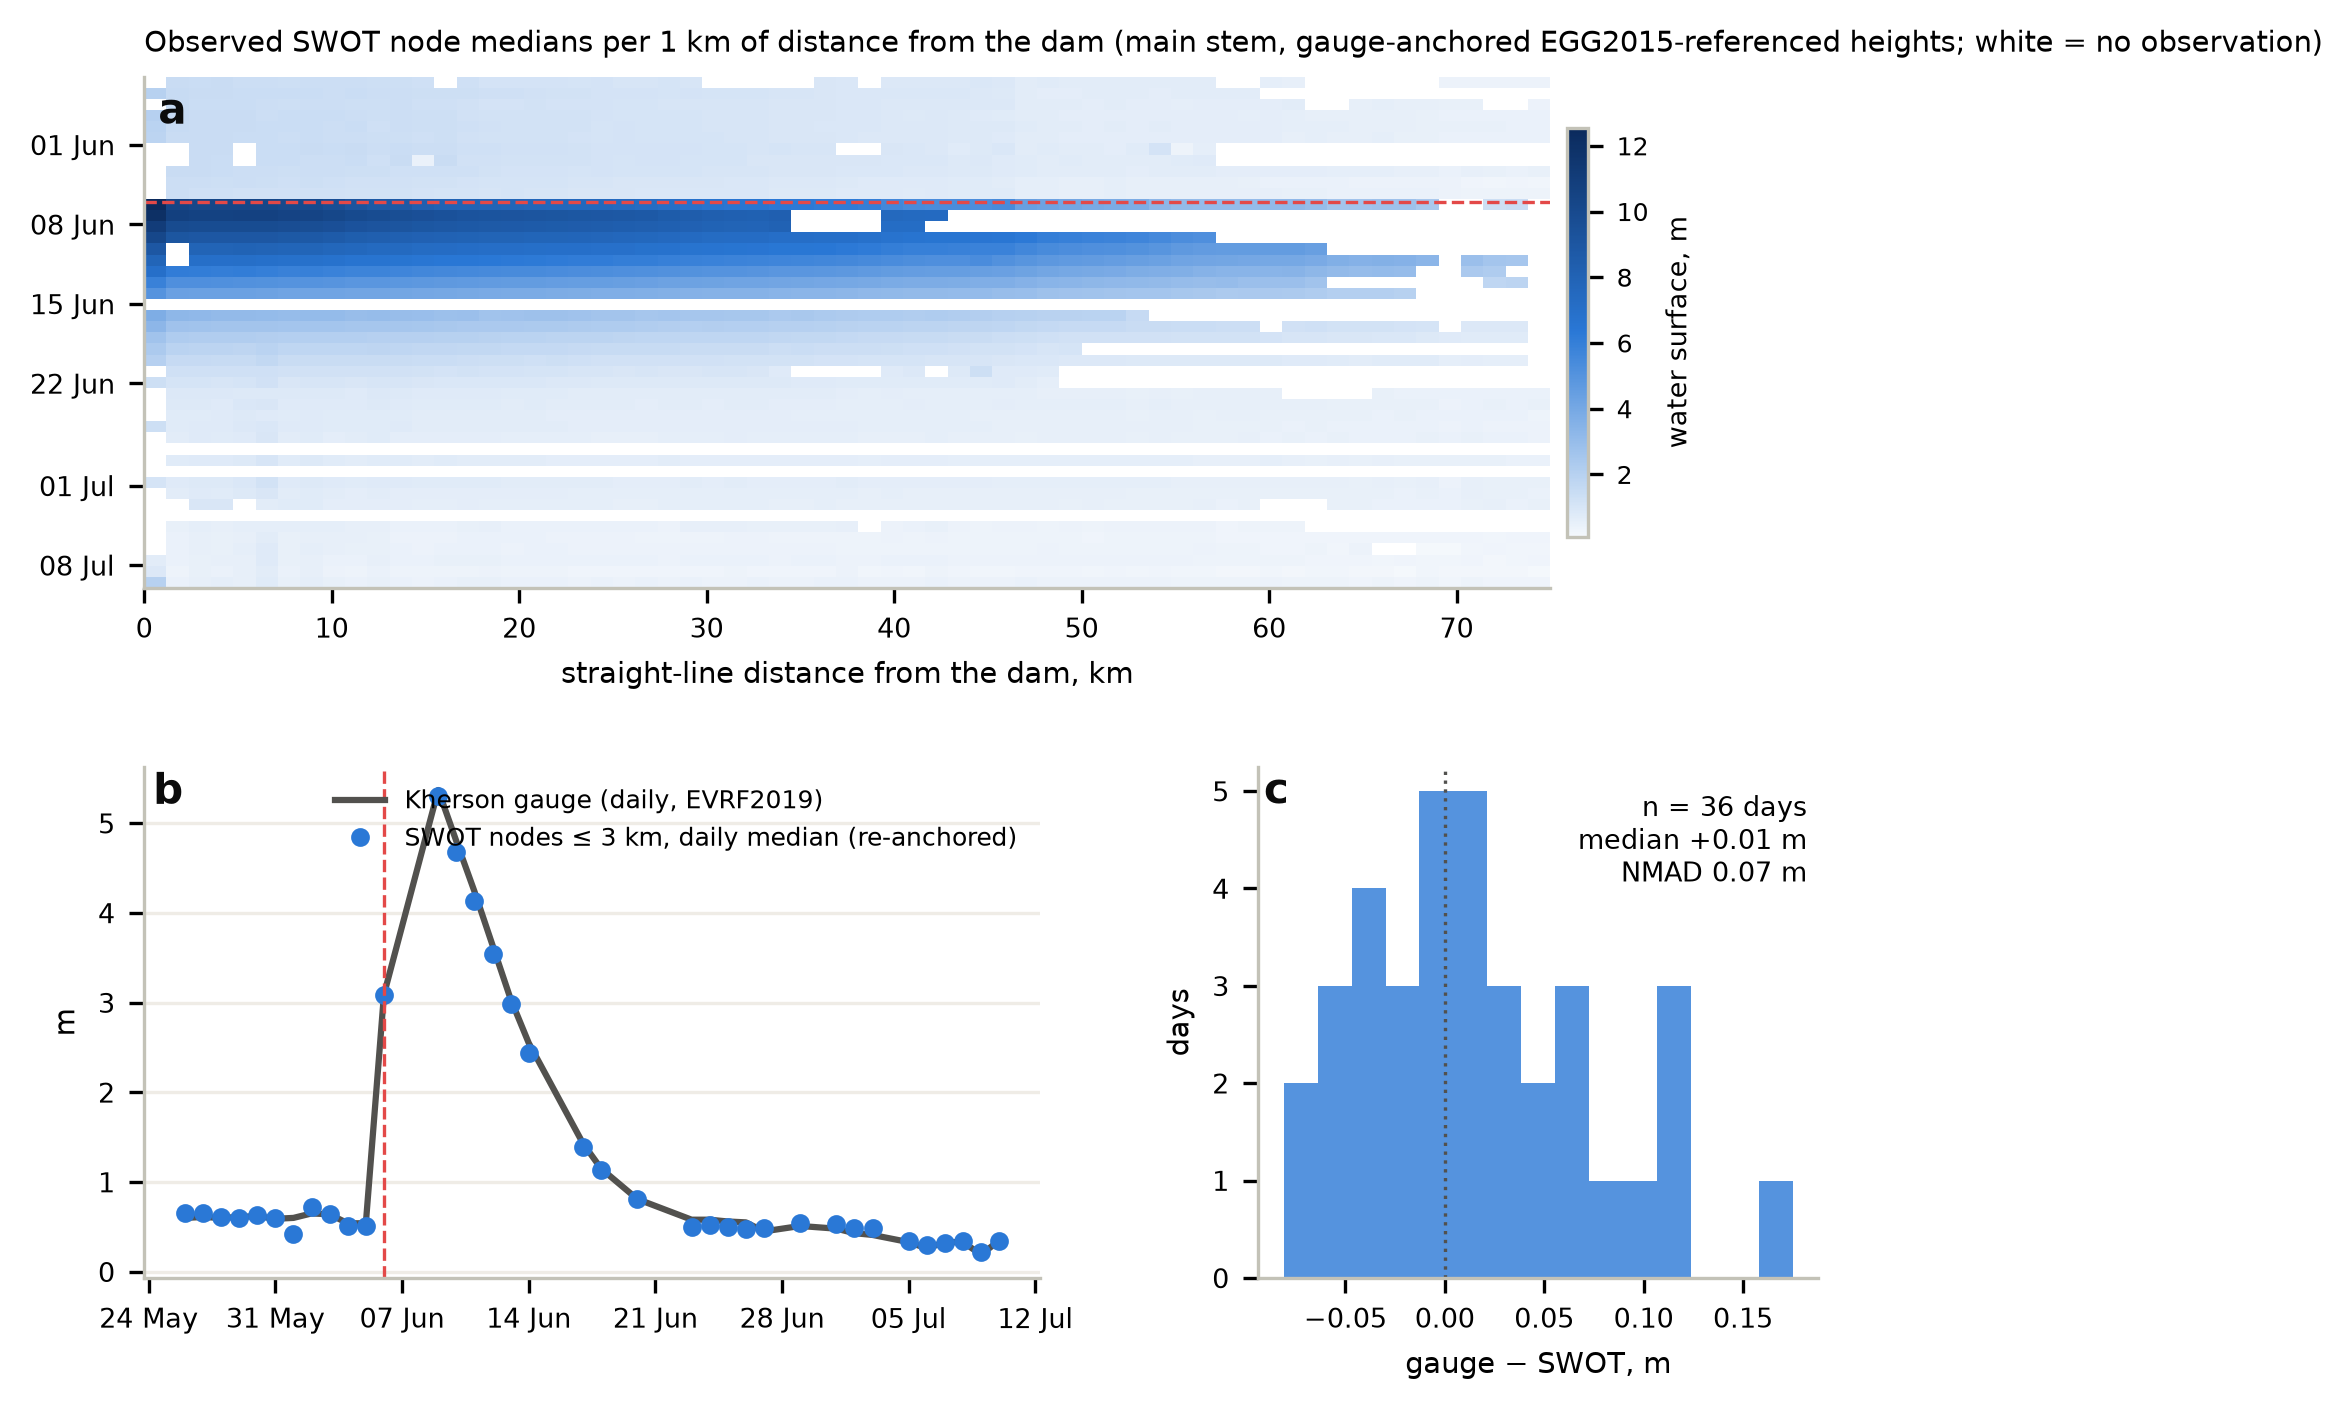

**T17** [independent_physical] SWOT-input consistency at Kherson after re-anchoring: nodes within 3 km of the gauge, daily median vs the daily gauge (river yearbook, EVRF2019). The frame validation itself is Paper 1; this only checks the p95 input.

,period,n_days,bias_m,median_m,MAE_m,RMSE_m,NMAD_m,min_m,max_m,independent_unit,sign
0,all days,36,0.016,0.006,0.048,0.062,0.066,-0.081,0.175,day (one 11:00 UTC overpass vs a date-only dai...,gauge - satellite (Paper 1 convention); satell...
1,pre-breach 05-26..06-05,11,0.003,-0.008,0.041,0.063,0.051,-0.070,0.175,day (one 11:00 UTC overpass vs a date-only dai...,gauge - satellite (Paper 1 convention); satell...
2,rise and peak 06-06..06-14,7,0.082,0.103,0.082,0.090,0.022,0.010,0.118,day (one 11:00 UTC overpass vs a date-only dai...,gauge - satellite (Paper 1 convention); satell...
3,recession 06-15..07-10,18,-0.002,-0.007,0.038,0.045,0.048,-0.081,0.076,day (one 11:00 UTC overpass vs a date-only dai...,gauge - satellite (Paper 1 convention); satell...


In [3]:
fig('Fig06'); show('T17')

## 2. Daily terrain-reconstructed inundation (area, volume) with the Monte-Carlo band

In [4]:
d = show('T12'); d[d.region == 'DNIPRO_CORRIDOR'][['date','A_central_km2','A_p05_km2','A_p95_km2','V_central_hm3','V_p05_hm3','V_p95_hm3','A_hand_and_ceiling_km2','A_ceiling_only_km2']]

**T12** [independent_physical] Daily terrain-reconstructed inundation per region and key date: TOTAL water surface (W_total_*: all water on the day incl. pre-breach channels, lakes and reed beds; p05..p95 of 100 000 emulator draws) and NEW inundation (A_*: 40 spatial Monte-Carlo draws p05/p50/p95 and 100 000 emulator draws p05..p95), for the central run (DEM class-bias corrected), the p42 HAND rule, the ceiling-only variant, the uncorrected-DEM and superseded-closure sensitivities; volume of new water.

,date,A_central_km2,A_p05_km2,A_p95_km2,V_central_hm3,V_p05_hm3,V_p95_hm3,A_hand_and_ceiling_km2,A_ceiling_only_km2
0,2023-06-05,0.0,NaN,NaN,0.00,NaN,NaN,0.0,0.0
3,2023-06-06,180.1,184.3,199.7,373.08,399.7,434.1,194.9,190.4
6,2023-06-07,235.3,237.6,254.9,509.01,545.4,595.7,247.1,253.6
9,2023-06-08,224.7,226.4,249.6,472.88,510.6,560.0,238.7,237.2
12,2023-06-09,182.8,190.5,207.9,452.92,487.5,539.3,221.3,195.3
15,2023-06-10,156.1,NaN,NaN,406.45,NaN,NaN,210.1,169.6
18,2023-06-11,143.0,149.7,163.9,333.83,353.0,397.3,200.6,145.0
21,2023-06-12,128.5,NaN,NaN,244.03,NaN,NaN,183.7,126.5
24,2023-06-13,108.4,114.3,128.7,165.09,177.5,204.0,159.7,108.3
27,2023-06-14,87.6,92.9,106.8,106.71,111.6,133.4,142.7,87.8


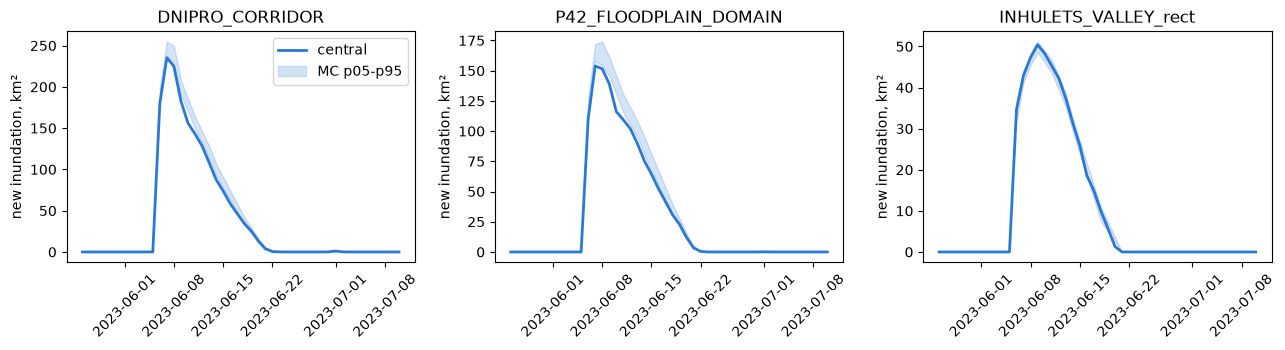

In [5]:
u = pd.read_csv(T / "p95e_area_volume_uncertainty.csv") if (T / "p95e_area_volume_uncertainty.csv").exists() else None
dd = pd.read_csv(T / "p95_daily_area_pooled_connected_ceiling.csv"); dd["t"] = pd.to_datetime(dd.date)
fig_, axs = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, r in zip(axs, ["DNIPRO_CORRIDOR", "P42_FLOODPLAIN_DOMAIN", "INHULETS_VALLEY_rect"]):
    s = dd[dd.region == r]; ax.plot(s.t, s.new_km2, color=C["terrain"], lw=2, label="central")
    if u is not None:
        uu = u[u.region == r].copy(); uu["t"] = pd.to_datetime(uu.date); uu = uu.sort_values("t"); ax.fill_between(uu.t, uu.A_p05_km2, uu.A_p95_km2, color=C["terrain"], alpha=0.2, label="MC p05-p95")
    ax.set_title(r); ax.set_ylabel("new inundation, km²"); ax.tick_params(axis="x", rotation=45)
axs[0].legend(); plt.tight_layout()

In [6]:
show('T11b')

**T11b** [independent_physical] Uncertainty components of the terrain reconstruction (Monte-Carlo inputs): closure, gauge, SWOT node height, per-node time interpolation, DEM error by WorldCover class (Paper 2 / p57).

,component,sigma_m,applied,source,bias_m,rmse_m,n
0,closure_kherson,0.050,"one offset per draw, all cells",Paper 1 Table 5 / Sec. 5.12 (NMAD 4-5 cm at Kh...,NaN,NaN,NaN
1,gauge_daily,0.050,"per draw, cells > 15 km from a node (gauge cap)",date-only daily values; two yearbooks differ b...,NaN,NaN,NaN
2,swot_node_wse_u,0.092,"per (day, 1-km bin), 5-km smoothed field","p59 nodes, median wse_u",NaN,NaN,NaN
3,"H(s,t)_interpolation",0.054,"interpolated cells only, per (day, bin), 5-km ...",leave-one-out NMAD on 17313 observed cells,NaN,NaN,NaN
4,dem_trees,1.603,"class-wise sigma, spatially correlated field (...",/home/niko/repo/floodstate-eo/case_studies/kak...,1.481,3.024,8066.0
5,dem_grass,0.491,"class-wise sigma, spatially correlated field (...",/home/niko/repo/floodstate-eo/case_studies/kak...,0.107,1.329,29227.0
6,dem_cropland,0.195,"class-wise sigma, spatially correlated field (...",/home/niko/repo/floodstate-eo/case_studies/kak...,-0.059,0.408,95454.0
7,dem_built,0.696,"class-wise sigma, spatially correlated field (...",/home/niko/repo/floodstate-eo/case_studies/kak...,0.151,1.901,7850.0
8,dem_bare,1.188,"class-wise sigma, spatially correlated field (...",/home/niko/repo/floodstate-eo/case_studies/kak...,-0.574,3.375,287.0
9,dem_wetland,0.477,"class-wise sigma, spatially correlated field (...",/home/niko/repo/floodstate-eo/case_studies/kak...,0.509,1.131,12409.0


### 100 000 draws per day (cluster-normal emulator, p95g) -- candles of the total water surface

Text(0.5, 1.0, 'Dnipro corridor: 100 000 emulator draws per day (p05-p95 whisker, p25-p75 body)')

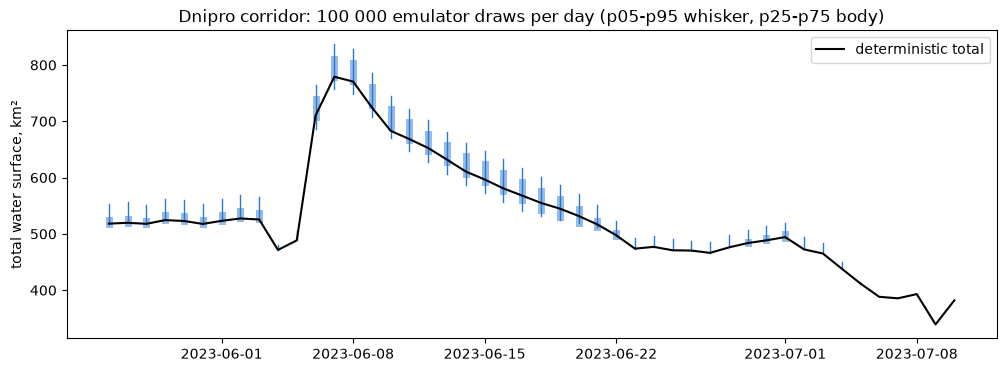

In [7]:
g = pd.read_csv(T / "p95g_mc_daily.csv"); gg = g[g.region == "DNIPRO_CORRIDOR"].copy(); gg["t"] = pd.to_datetime(gg.date)
fig_, ax = plt.subplots(figsize=(12, 4))
for _, q in gg.iterrows():
    ax.plot([q.t, q.t], [q.W_total_km2_p05, q.W_total_km2_p95], color=C["terrain"], lw=1); ax.plot([q.t, q.t], [q.W_total_km2_p25, q.W_total_km2_p75], color=C["terrain"], lw=5, alpha=0.5)
ax.plot(gg.t, gg.W_total_central_km2, color="k", lw=1.5, label="deterministic total"); ax.set_ylabel("total water surface, km²"); ax.legend(); ax.set_title("Dnipro corridor: 100 000 emulator draws per day (p05-p95 whisker, p25-p75 body)")

### Reservoir side of the balance (T21, T22, Fig09)

**T21** [independent_physical] Kakhovka pool during the drawdown, per day: levels at the outlet (SWOT), Nikopol (press) and Rozumivka (gauge), surface gradient, pool water area and volume under the sloped surface (seamless DEM inside the pre-breach pool polygon), daily volume change, DniproHES inflow, implied breach outflow, and the downstream new-water volume and total water surface (terrain reconstruction) with the Kherson stage.

**T22** [independent_physical] Pool hypsometry from the seamless DEM (level surface) against the design Table 19 (BS-77 levels + 0.185 m).

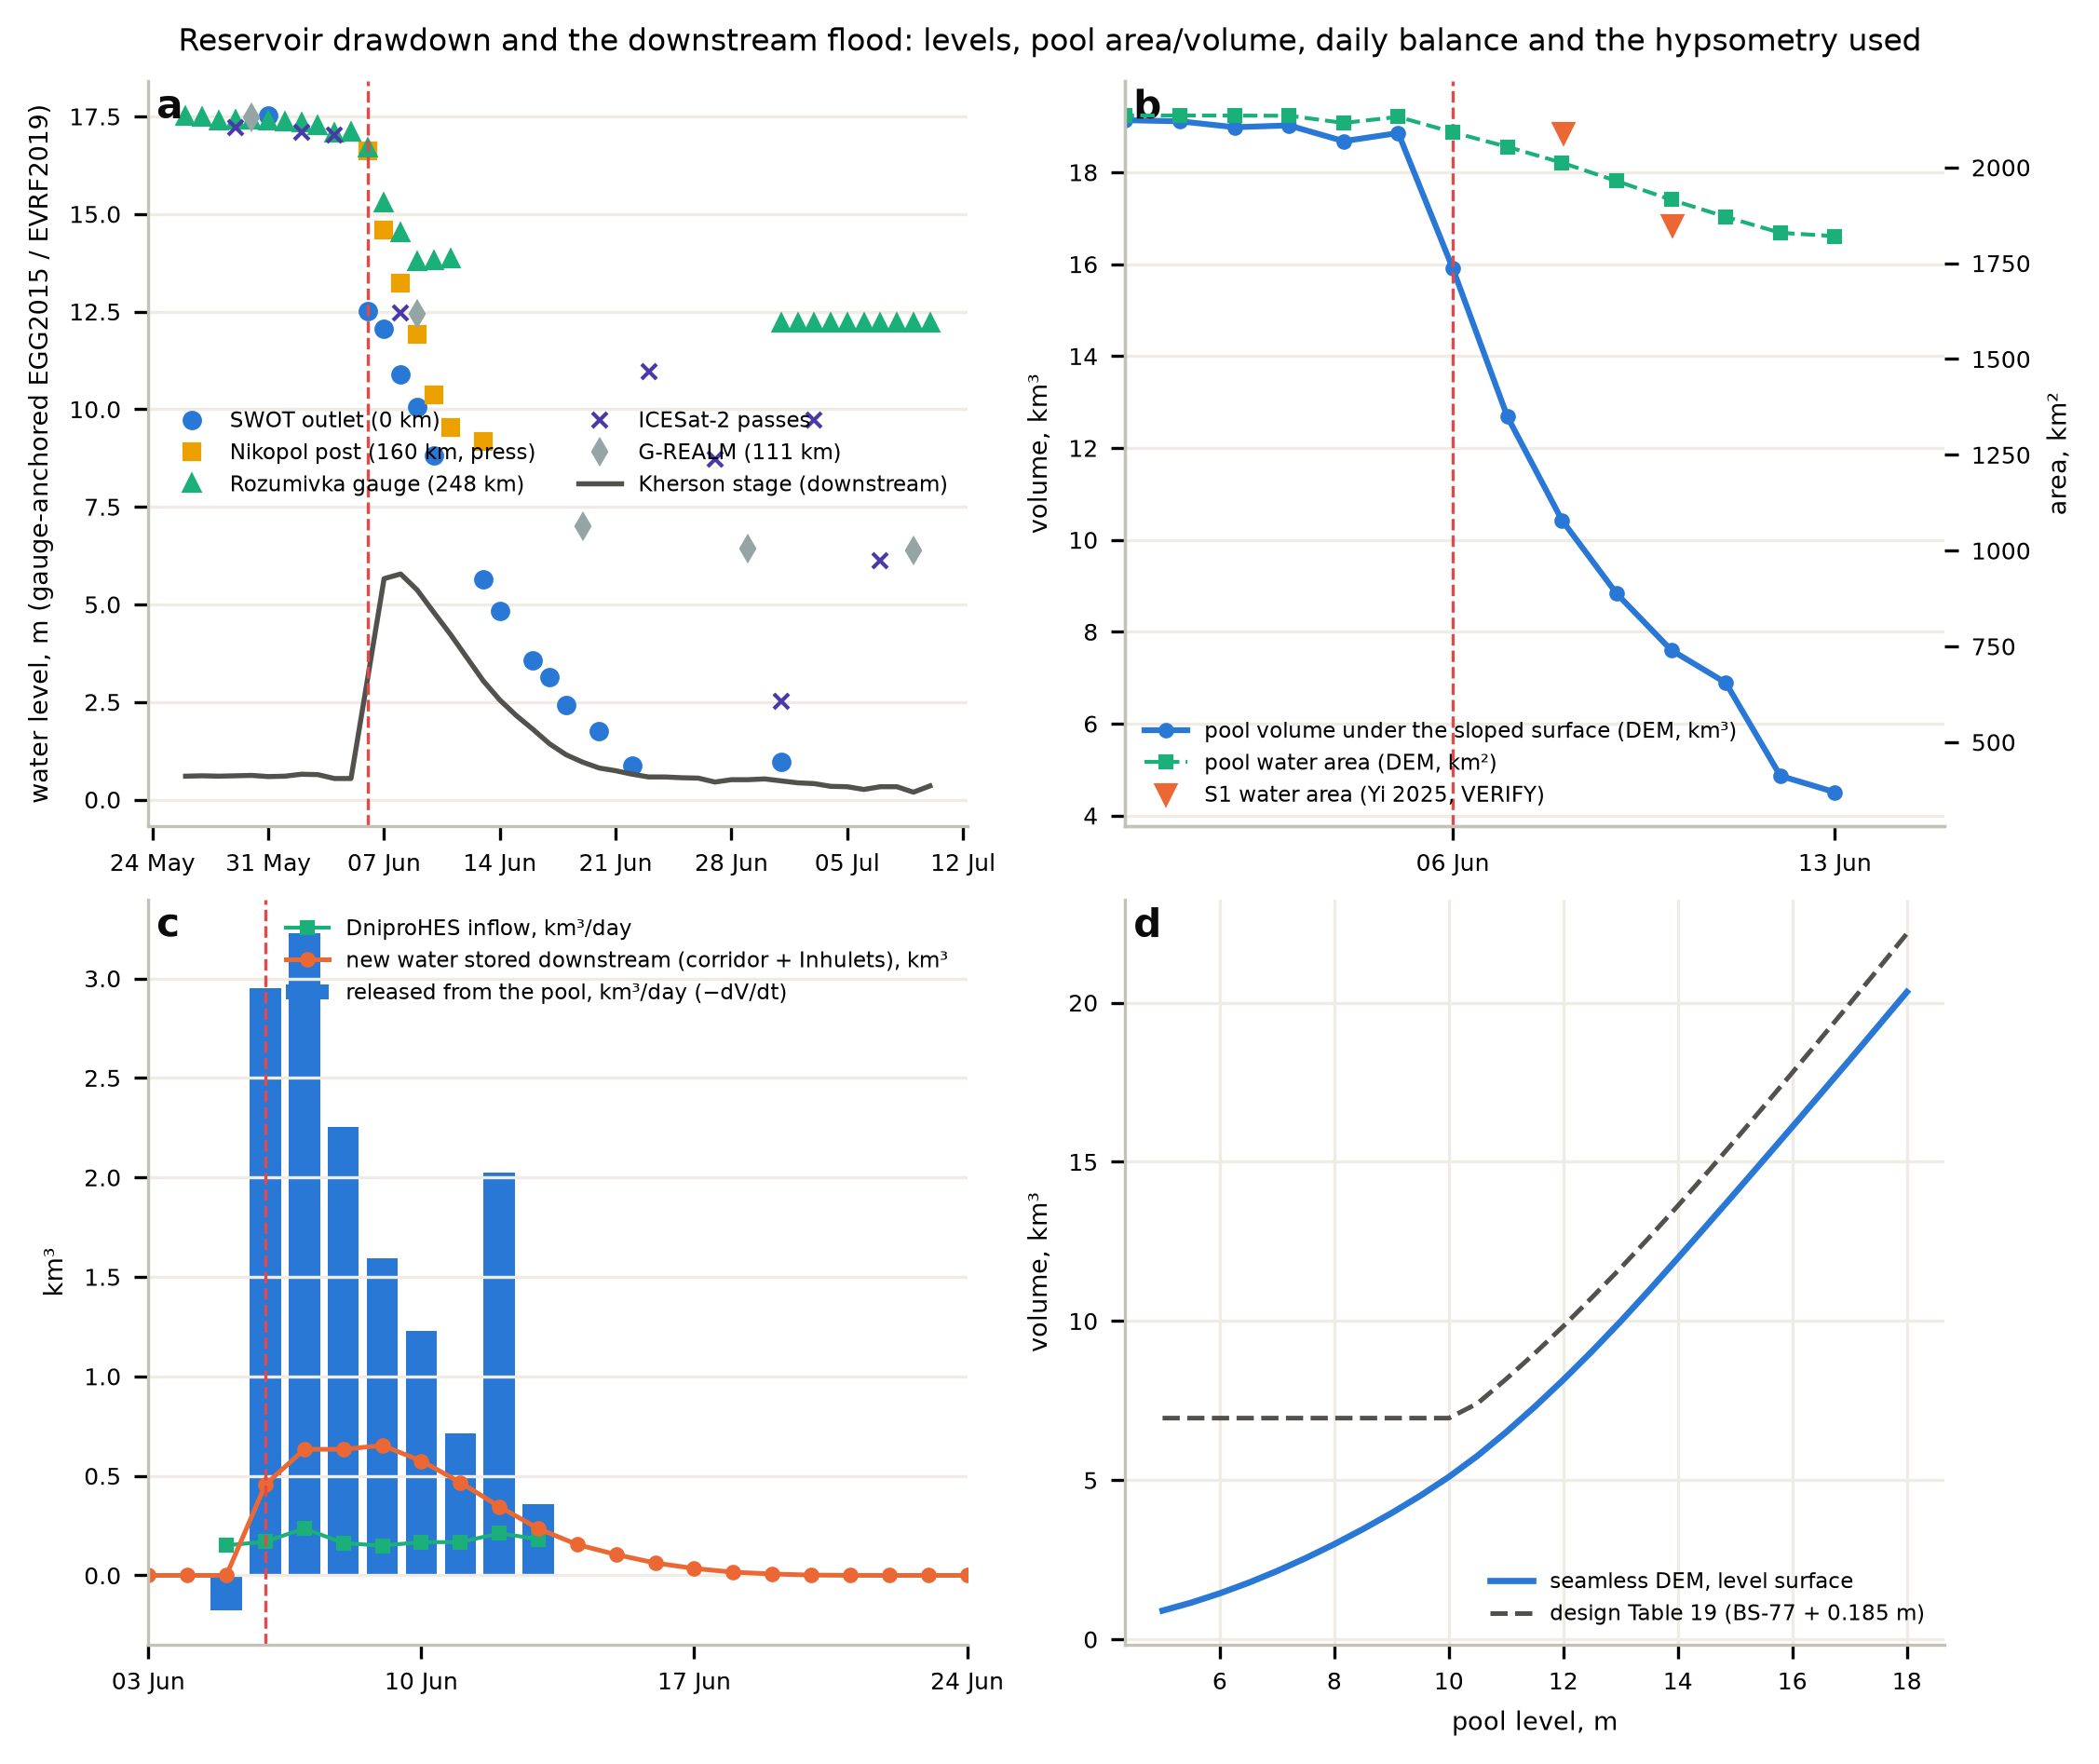

In [8]:
show('T21'); show('T22'); fig('Fig09')

## 3. Cross-sensor check against Sentinel-1 (per acquisition date)
POD / FAR / CSI on the S1 observation domain are primary; POD excluding normally-wet cells is a sensitivity with an a-priori rule.

In [9]:
v = show('T13'); v[(v.variant == 'connected_ceiling') & v.date.isin(['2023-06-09','2023-06-13','2023-06-14','2023-06-18','2023-06-21'])][['date','region','s1_new_km2','hand_new_km2','hit_km2','miss_km2','miss_on_normally_wet_km2','hand_only_km2','POD','FAR','CSI','POD_excl_normally_wet']]

**T13** [cross_sensor] Terrain reconstruction vs Sentinel-1 new dark water per acquisition date, region and variant: hit / miss / miss-on-normally-wet / terrain-only km2, POD, FAR, CSI (primary) and POD excluding normally-wet cells (sensitivity).

,date,region,s1_new_km2,hand_new_km2,hit_km2,miss_km2,miss_on_normally_wet_km2,hand_only_km2,POD,FAR,CSI,POD_excl_normally_wet
75,2023-06-09,DNIPRO_CORRIDOR,319.4,178.5,58.8,260.7,173.5,119.7,0.184,0.671,0.134,0.403
76,2023-06-09,INHULETS_VALLEY_rect,36.2,20.5,14.6,21.7,13.6,6.0,0.402,0.291,0.345,0.643
77,2023-06-09,P42_FLOODPLAIN_DOMAIN,201.2,135.8,51.8,149.5,147.5,84.1,0.257,0.619,0.181,0.963
78,2023-06-13,DNIPRO_CORRIDOR,164.9,107.9,23.4,141.5,129.6,84.5,0.142,0.783,0.094,0.663
79,2023-06-13,INHULETS_VALLEY_rect,27.0,16.1,12.4,14.6,14.1,3.7,0.459,0.230,0.404,0.961
80,2023-06-13,P42_FLOODPLAIN_DOMAIN,147.3,89.3,22.7,124.7,121.6,66.7,0.154,0.746,0.106,0.880
81,2023-06-14,DNIPRO_CORRIDOR,99.3,87.3,11.8,87.5,64.5,75.5,0.119,0.865,0.068,0.339
82,2023-06-14,INHULETS_VALLEY_rect,25.4,15.0,10.9,14.5,13.6,4.1,0.429,0.273,0.369,0.924
83,2023-06-14,P42_FLOODPLAIN_DOMAIN,74.0,75.0,11.5,62.6,59.4,63.5,0.155,0.847,0.084,0.782
84,2023-06-18,DNIPRO_CORRIDOR,53.6,28.3,0.4,53.2,5.2,27.8,0.007,0.986,0.005,0.008


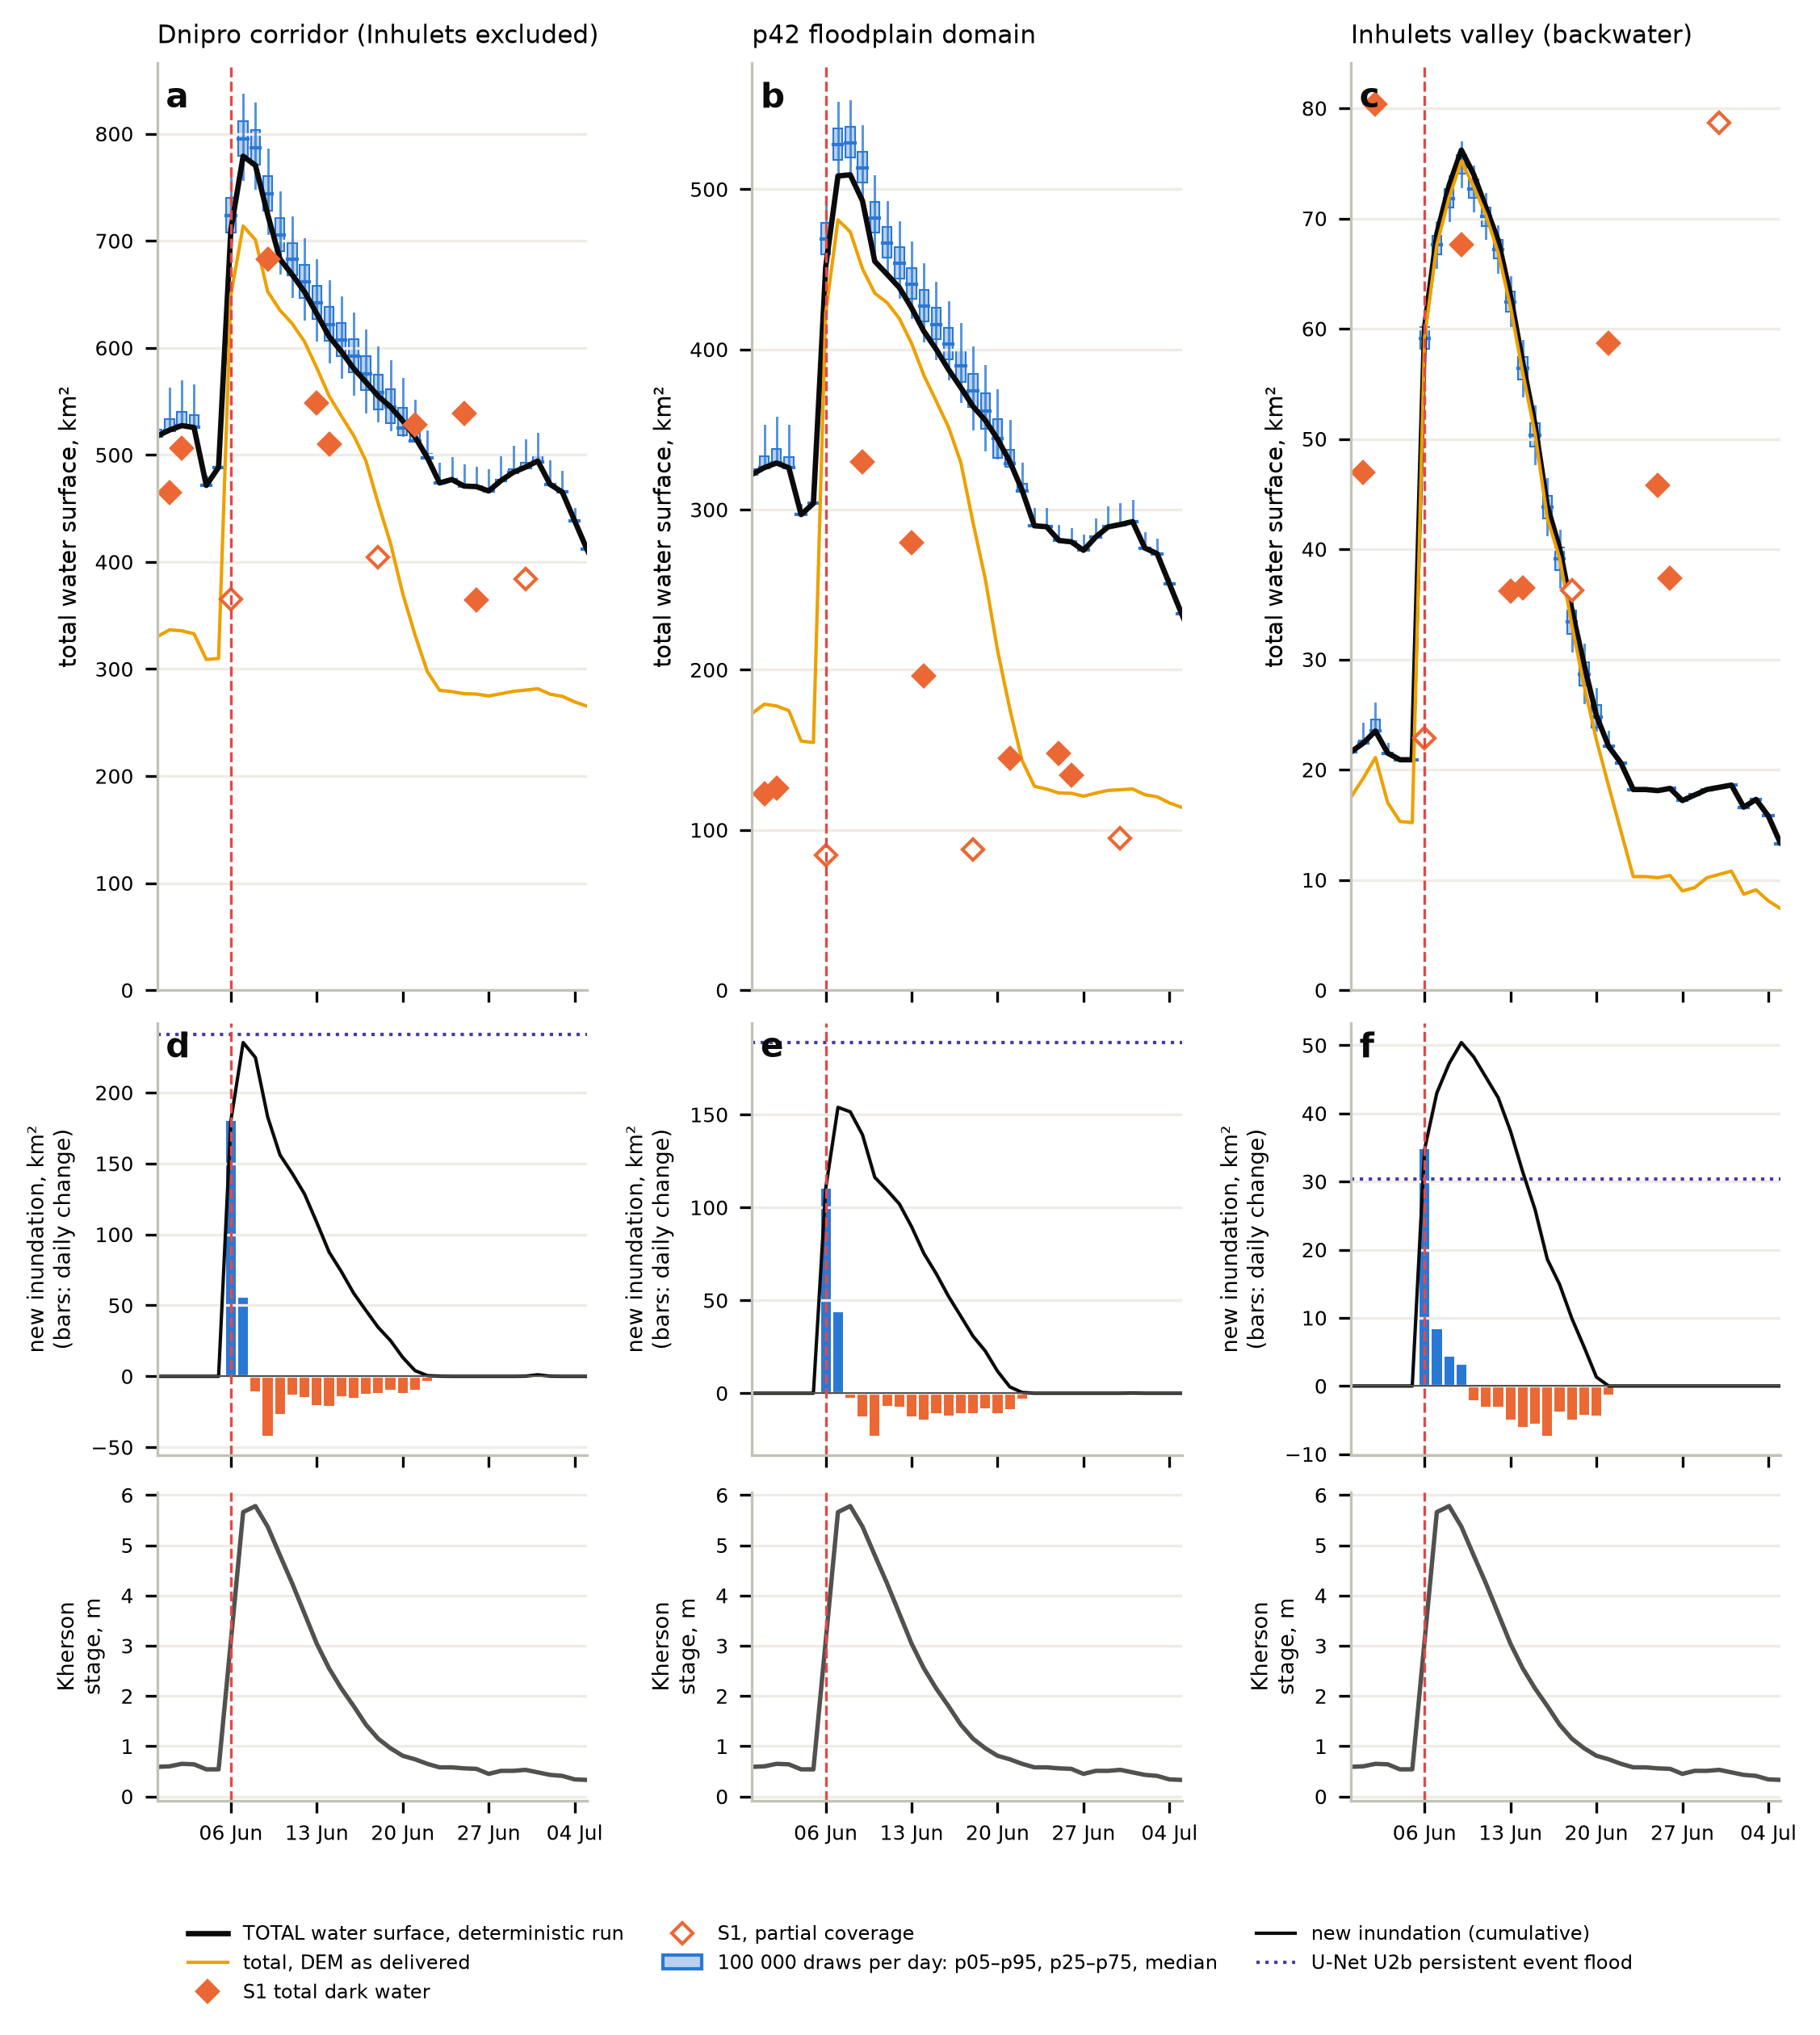

In [10]:
fig('Fig04')

## 4. Disagreement ontology (A both / B terrain-only / C S1-only)
B decomposed by land cover (SAR blind spots); C by ground elevation relative to the surface (submergence vs false SAR water).

In [11]:
o = show('T14'); o[o.date == '2023-06-09']

**T14** [contextual] Disagreement ontology terrain x Sentinel-1 by zone and date: category areas split by ground elevation relative to the water surface, normally-wet flag, WorldCover and RF20 classes (km2).

,zone,date,category,km2,km2_ground_below_surface,km2_ground_0_2m_above,km2_ground_2_5m_above,km2_ground_ge5m_above,km2_normally_wet,km2_wc_trees,km2_wc_wetland,km2_wc_built,km2_wc_cropland,km2_wc_grass,km2_wc_bare,km2_p73_reed,km2_p73_forest,km2_p73_built,km2_p73_cropland,category_meaning
0,ZONE_4_DAM_TO_KHERSON_FLOODWAY,2023-06-09,A,25.82,25.82,0.00,0.00,0.00,0.00,0.93,6.15,0.65,0.98,16.65,0.07,5.46,1.44,1.48,1.06,terrain+ / S1+
1,ZONE_4_DAM_TO_KHERSON_FLOODWAY,2023-06-09,B,66.28,66.28,0.00,0.00,0.00,0.00,27.80,5.75,9.52,1.12,21.41,0.05,4.94,25.65,11.55,1.31,terrain+ / S1- (sensor blind spot or reconstru...
2,ZONE_4_DAM_TO_KHERSON_FLOODWAY,2023-06-09,C,109.07,75.09,1.44,3.46,29.08,74.29,2.78,69.09,0.13,25.63,9.26,0.21,69.90,2.75,0.34,5.94,terrain- / S1+ (submergence signal on normally...
3,ZONE_4_DAM_TO_KHERSON_FLOODWAY,2023-06-09,N,1870.95,305.79,96.60,199.53,1268.69,57.96,250.69,18.88,81.21,866.96,404.95,7.24,30.36,210.29,81.92,442.01,neither
4,ZONE_2_KHERSON_DELTA,2023-06-09,A,32.98,32.98,0.00,0.00,0.00,0.00,0.48,24.06,1.02,0.37,6.54,0.08,21.59,0.65,2.27,0.46,terrain+ / S1+
5,ZONE_2_KHERSON_DELTA,2023-06-09,B,53.39,53.39,0.00,0.00,0.00,0.00,15.56,14.39,13.75,0.18,8.98,0.08,12.20,13.98,16.43,0.18,terrain+ / S1- (sensor blind spot or reconstru...
6,ZONE_2_KHERSON_DELTA,2023-06-09,C,151.55,91.47,32.09,3.02,24.96,99.20,1.78,119.27,0.25,12.55,16.33,0.08,118.48,1.00,1.02,10.81,terrain- / S1+ (submergence signal on normally...
7,ZONE_2_KHERSON_DELTA,2023-06-09,N,883.09,168.62,51.50,36.28,619.94,36.41,117.21,59.55,75.86,289.25,205.21,2.01,67.21,102.38,85.97,246.57,neither


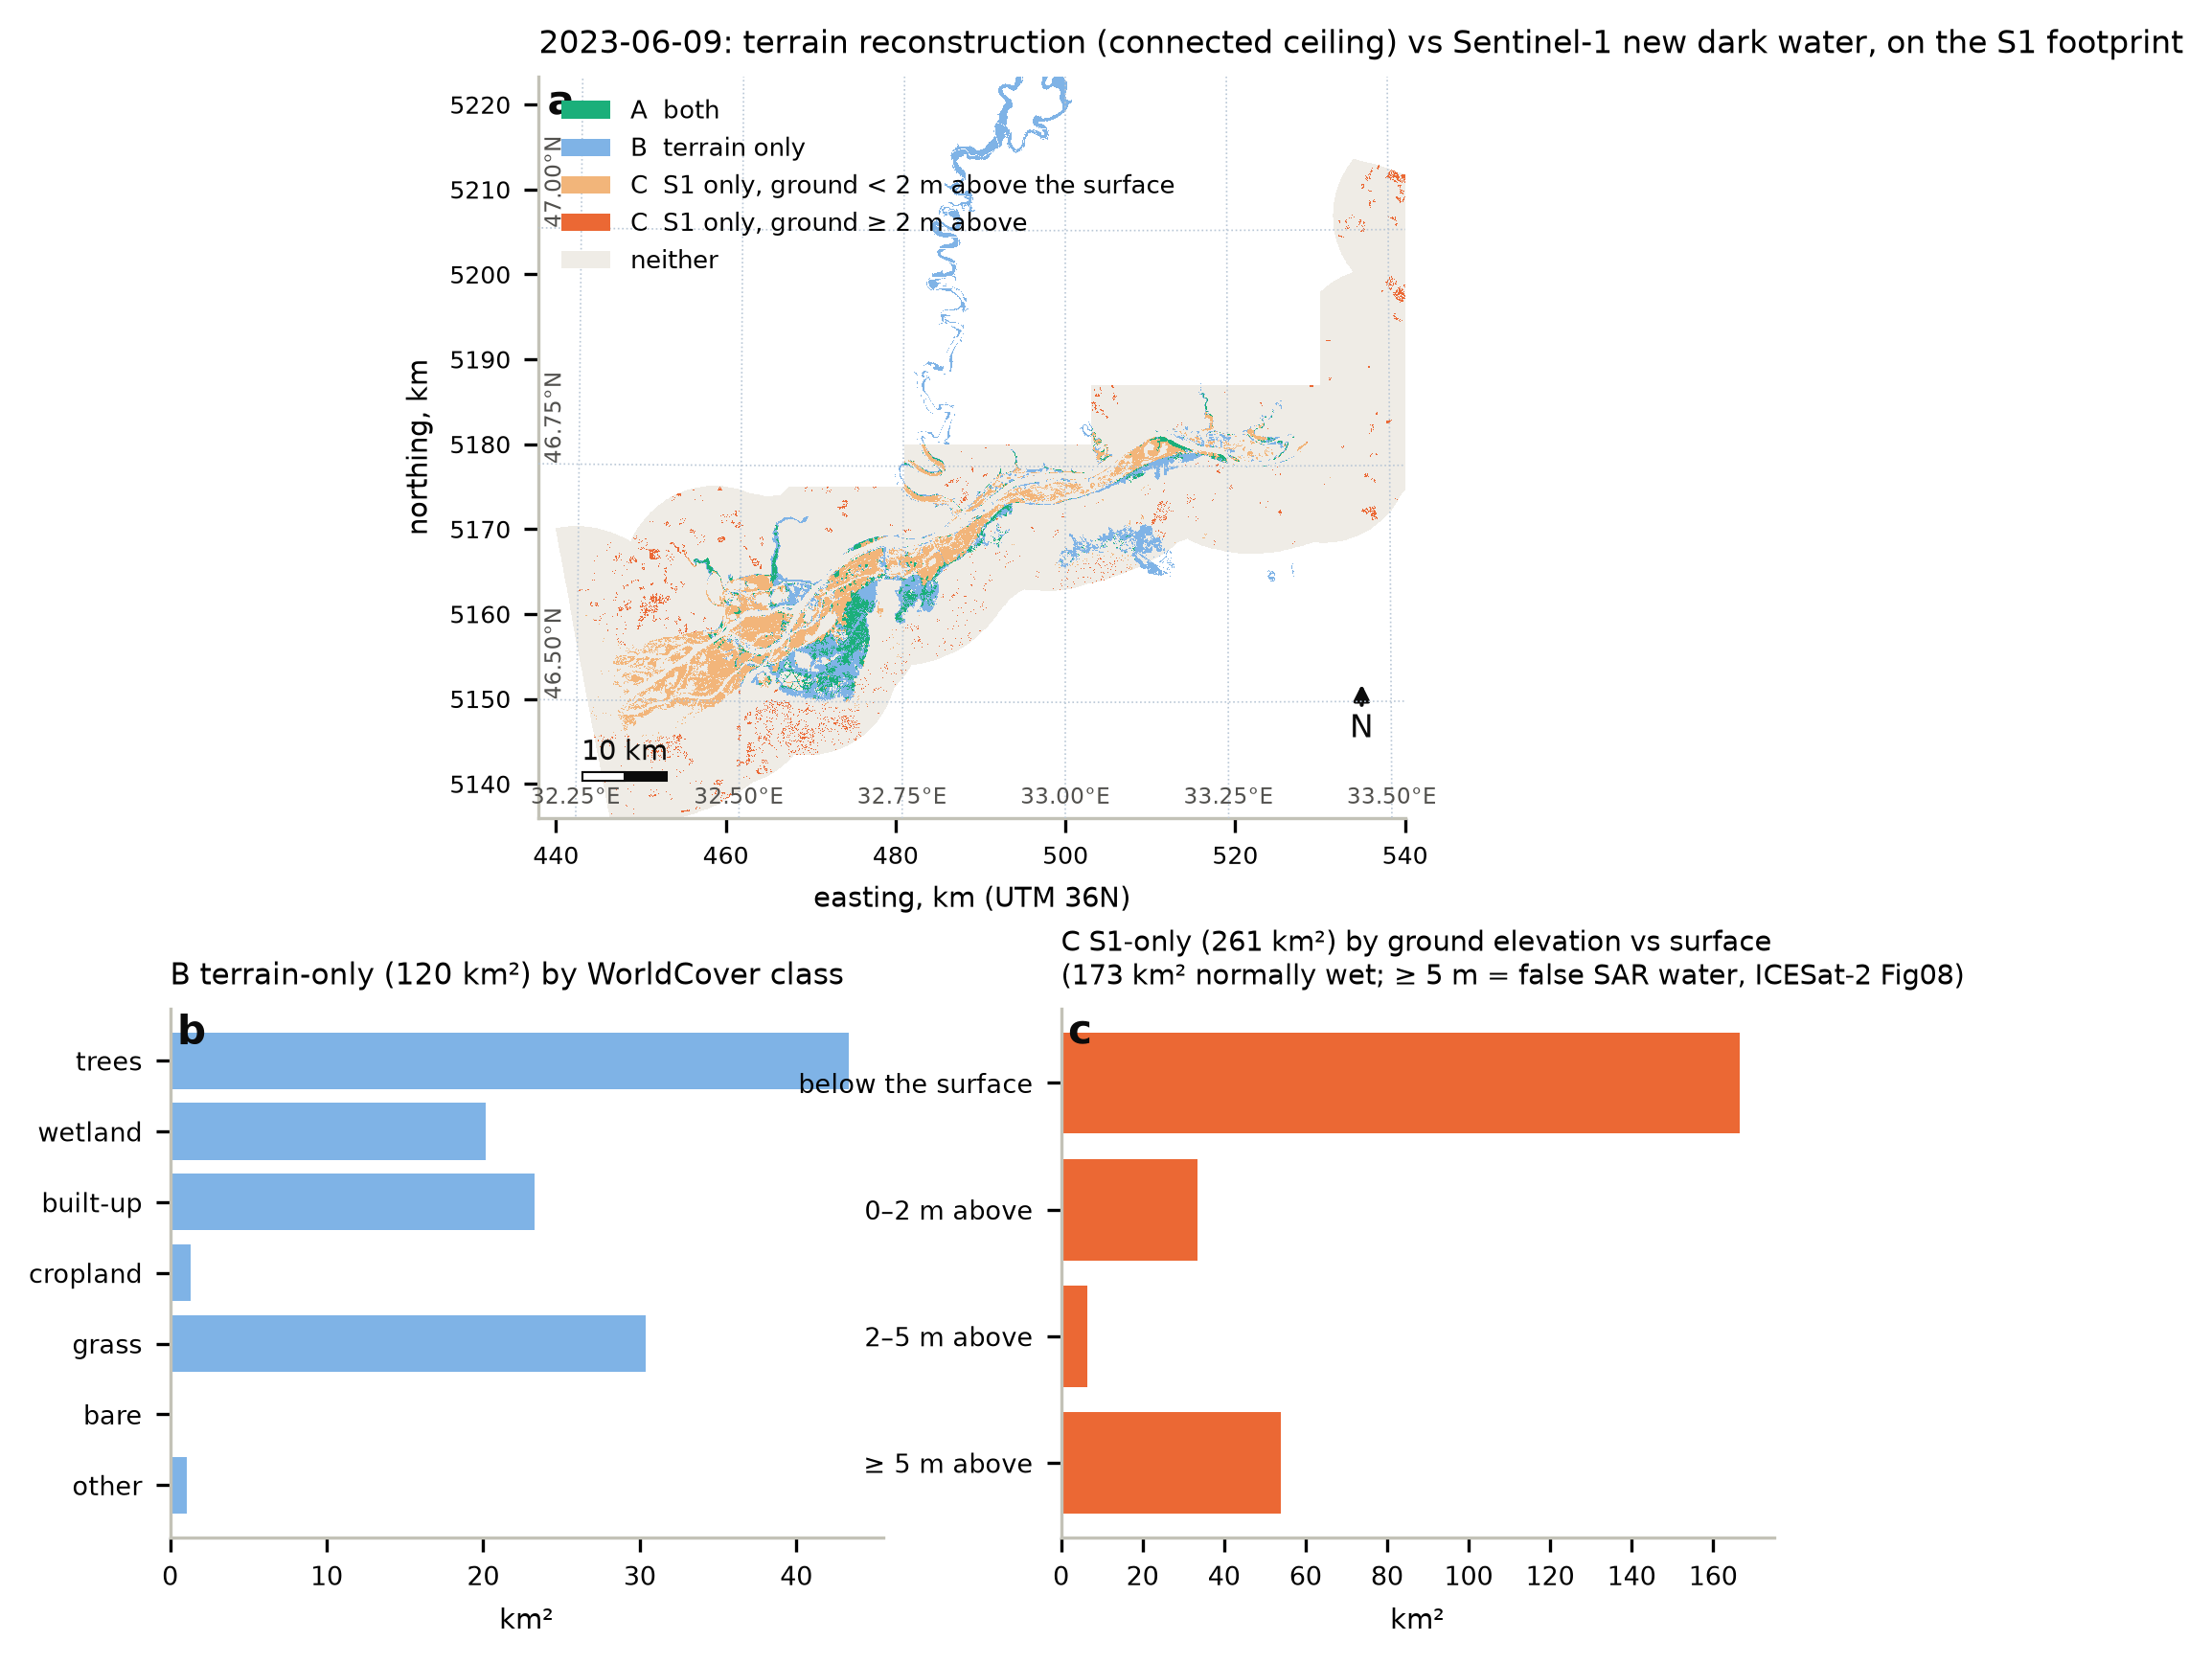

In [12]:
fig('Fig05')

## 5. ICESat-2 altimetric consistency check
A track-based consistency check of the DEM and the water surface, not a validation of the inundation map.

**T15** [independent_physical] ICESat-2 altimetric consistency check per zone and agreement category: residual seamless DEM minus ICESat-2 (median, p10, p90), ICESat-2 ground minus water surface, share of segments below the surface.

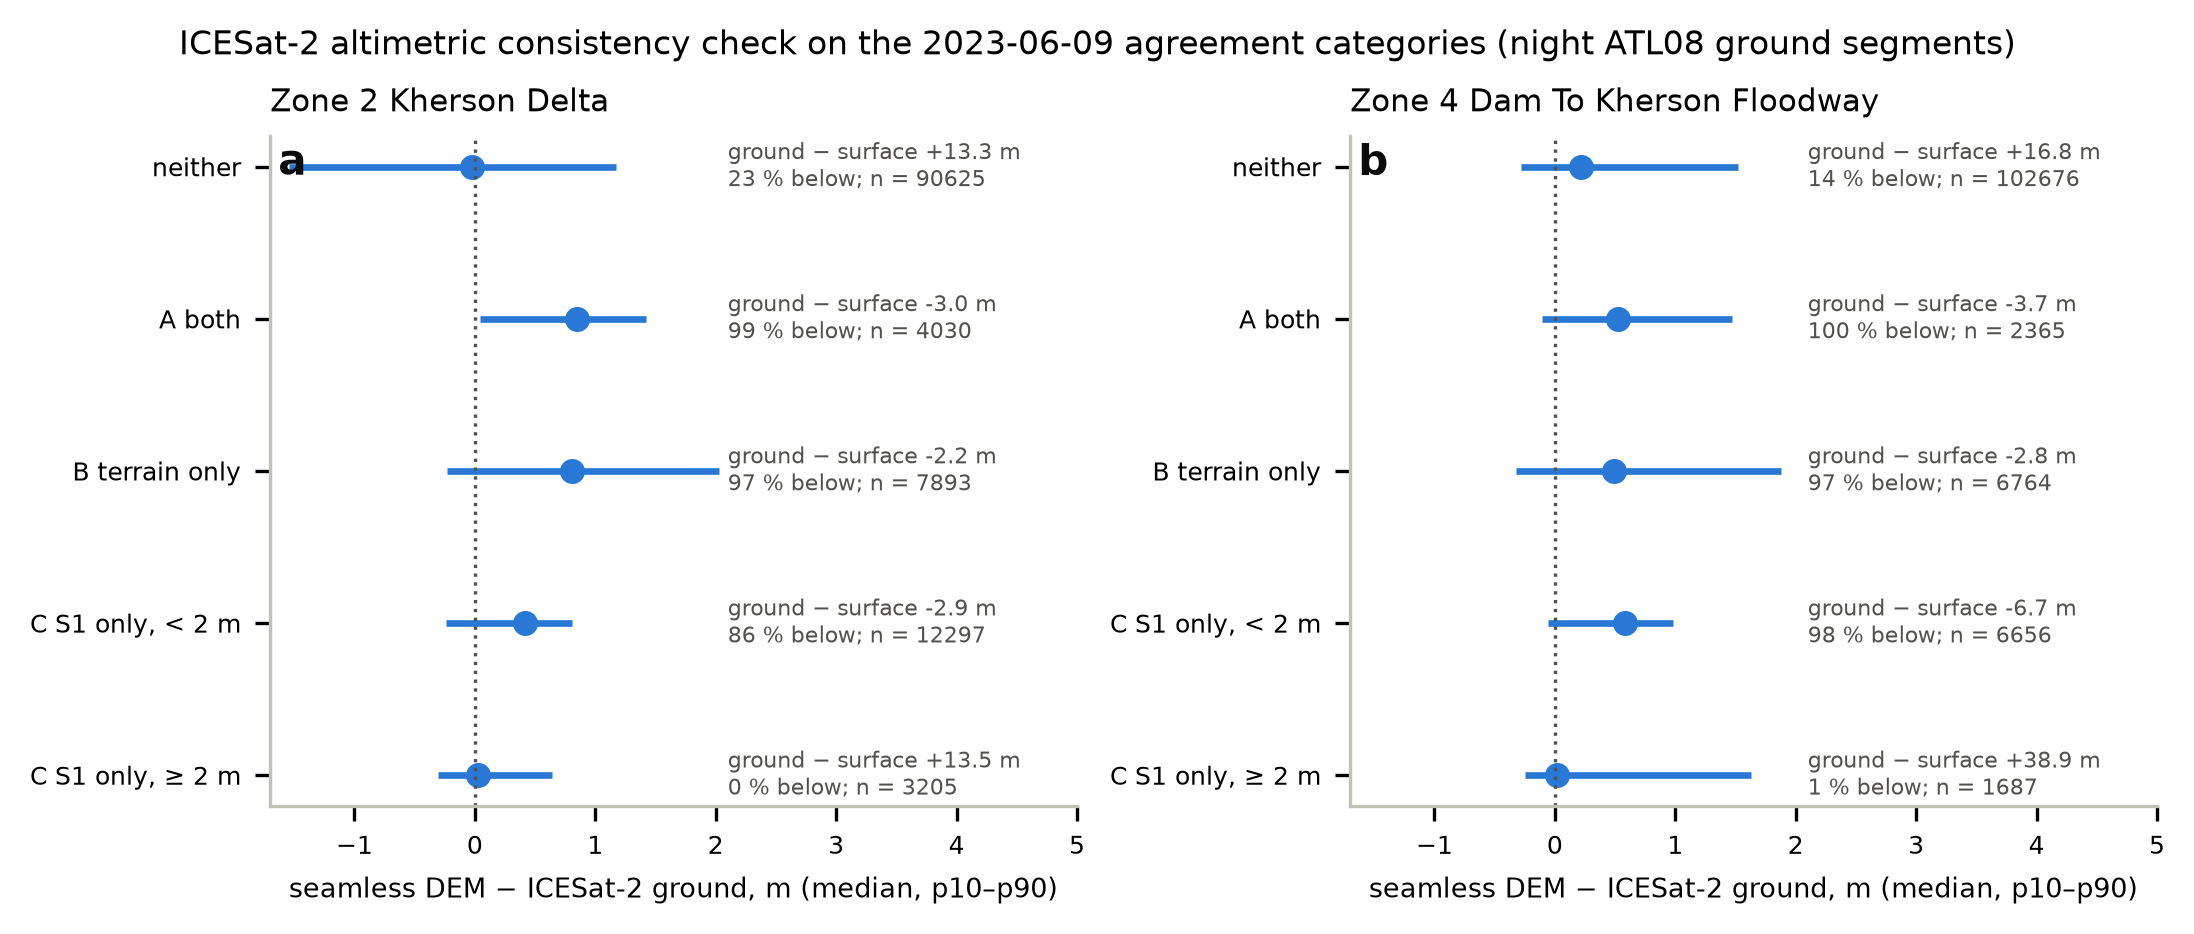

In [13]:
show('T15'); fig('Fig08')

## 6. Area accounting with semantics and the per-date series

In [14]:
show('T16')

**T16** [mixed] Area accounting with explicit semantics: observed (S1), mapped (U-Net), terrain-reconstructed and literature-reported figures are different quantities and are never compared as validation.

,region,quantity,km2,area_semantics,unobserved_km2,verify
0,DNIPRO_CORRIDOR,"S1 new dark water, 06-09 scene",299.6,observed_S1,NaN,NaN
1,DNIPRO_CORRIDOR,"S1 new dark water, >= 2 of 3 peak dates (label...",167.8,observed_S1,NaN,NaN
2,DNIPRO_CORRIDOR,"S1 total dark water, 06-09 (incl. pre-breach w...",682.5,observed_S1,NaN,NaN
3,DNIPRO_CORRIDOR,pre-breach water (S1 06-01/02 or p60 pre_water...,594.4,observed_S1,NaN,NaN
4,DNIPRO_CORRIDOR,U2b predicted event flood (persistent concept),241.0,mapped_UNet,NaN,NaN
5,INHULETS_VALLEY_rect,"S1 new dark water, 06-09 scene",36.1,observed_S1,NaN,NaN
6,INHULETS_VALLEY_rect,"S1 new dark water, >= 2 of 3 peak dates (label...",27.2,observed_S1,NaN,NaN
7,INHULETS_VALLEY_rect,"S1 total dark water, 06-09 (incl. pre-breach w...",67.6,observed_S1,NaN,NaN
8,INHULETS_VALLEY_rect,pre-breach water (S1 06-01/02 or p60 pre_water...,91.0,observed_S1,NaN,NaN
9,INHULETS_VALLEY_rect,U2b predicted event flood (persistent concept),30.4,mapped_UNet,NaN,NaN


**T19** [cross_sensor] Per-acquisition-date new water (not water before the breach) inside the Sentinel-1 observable domain, with coverage; S2 only where >= 30 % of the region was cloud-free; estuary zone on its own grid.

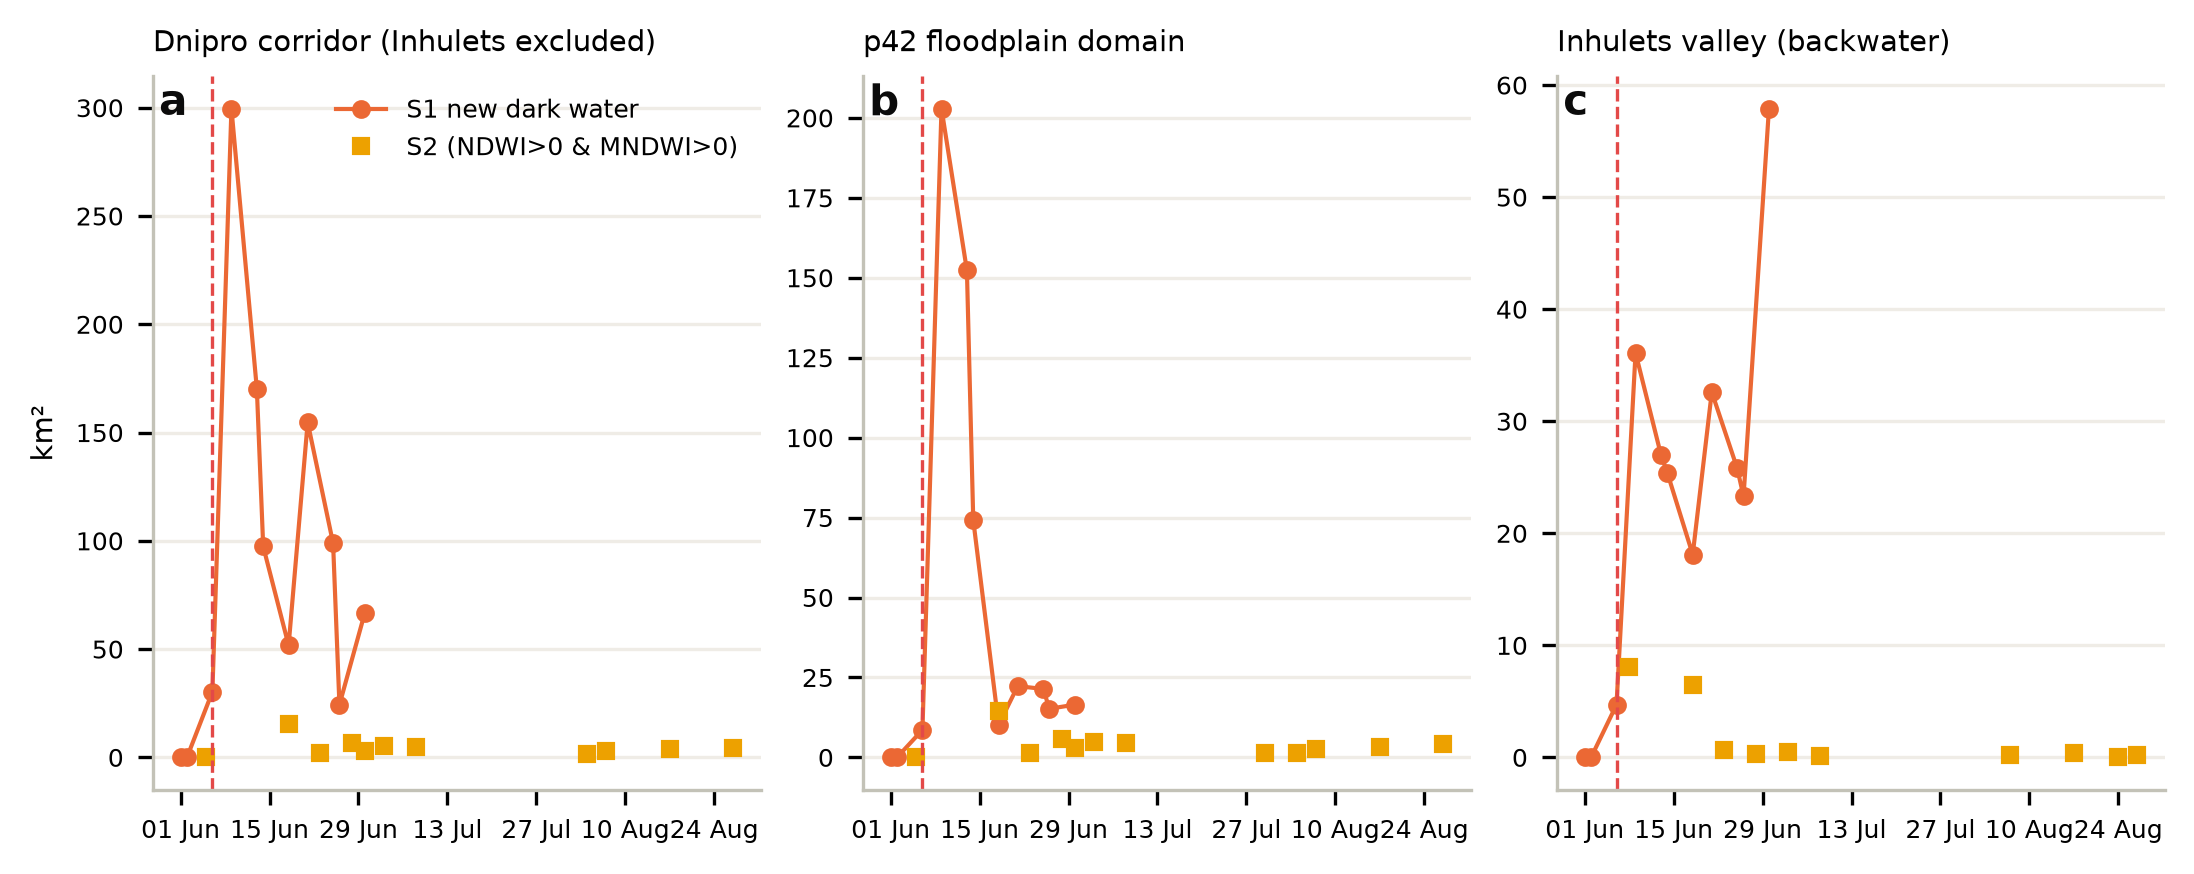

In [15]:
show('T19', 30); fig('FigS03')

## 7. Sensitivities
Rules, closure (superseded p59 chain) and the DEM accuracy that feeds the error model (Paper 2).

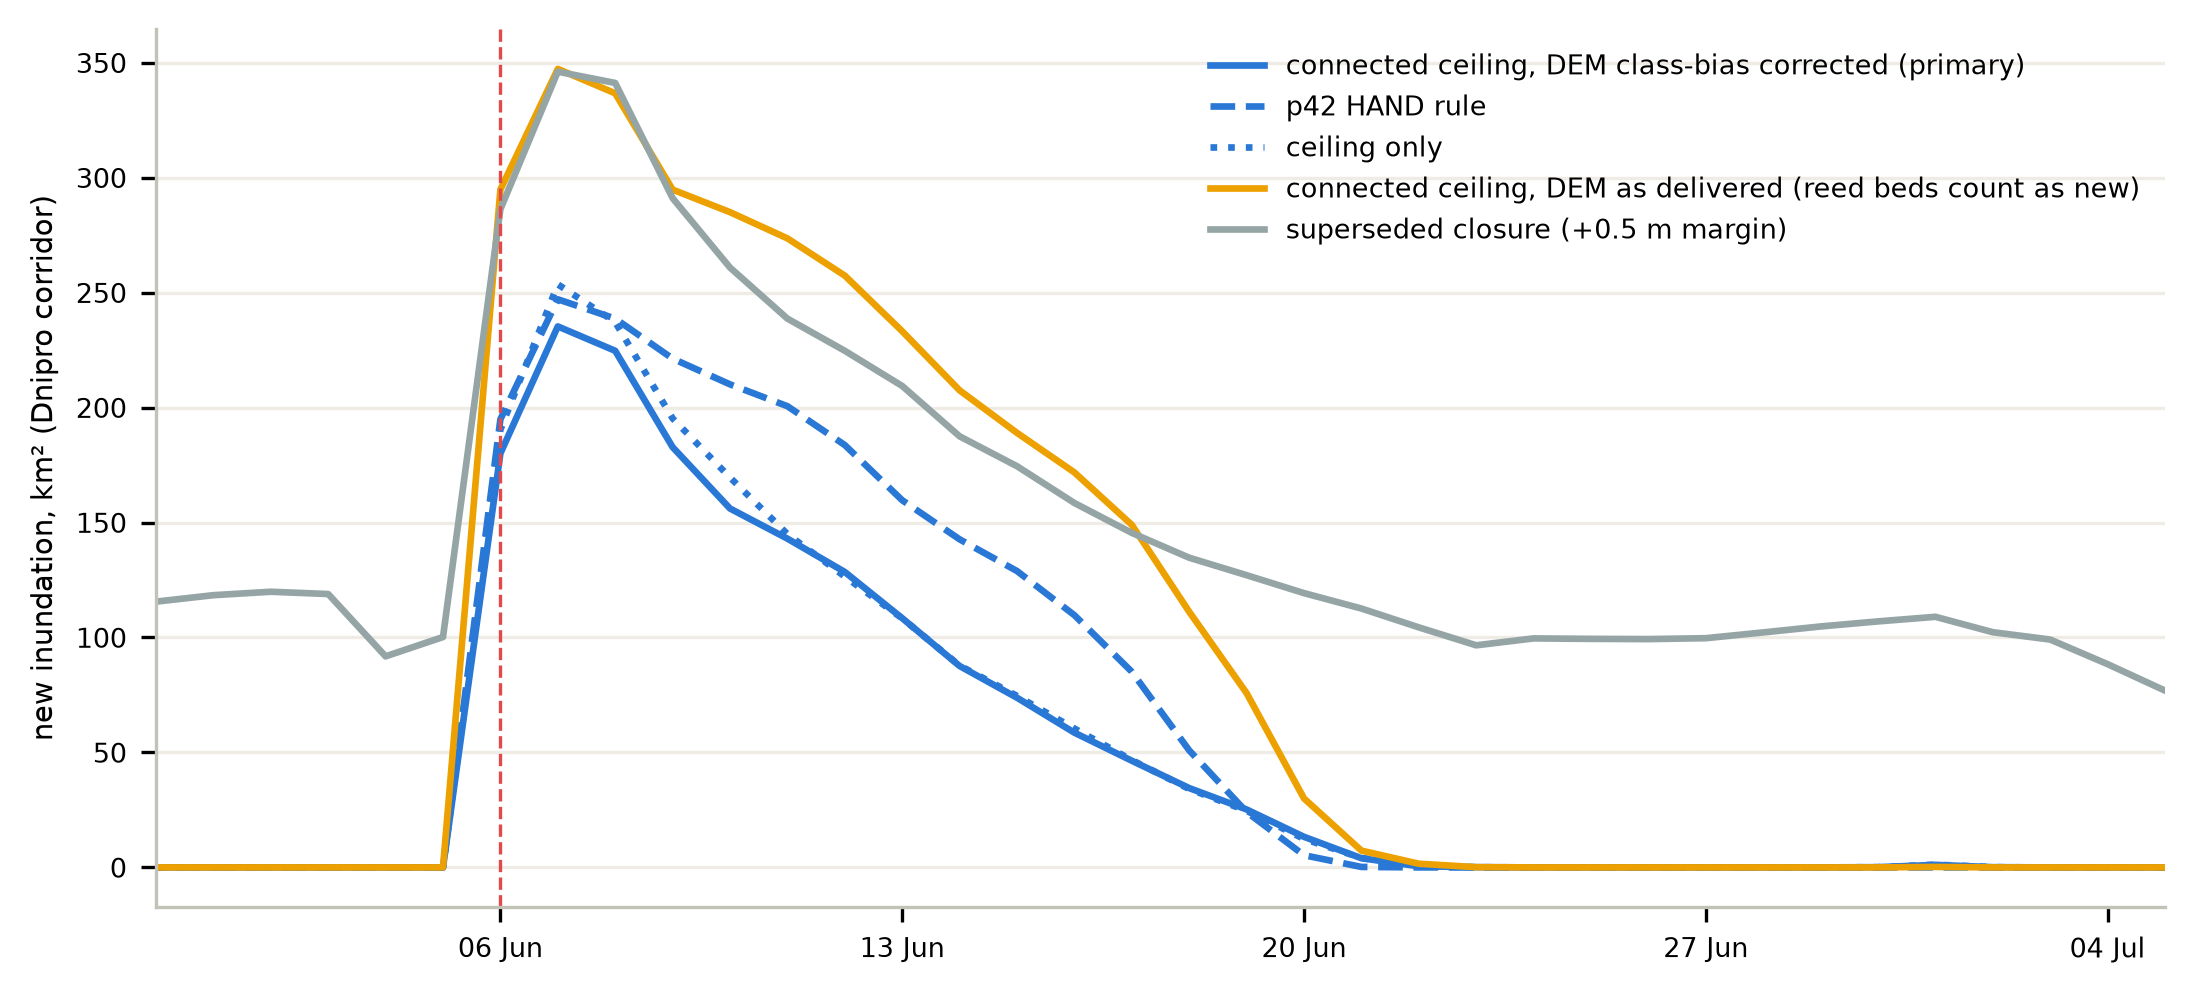

**T18** [independent_physical] Seamless DEM accuracy against night ICESat-2 ground segments (Paper 2): RMSE, MAE, bias, median, LE90, LE95, NMAD by zone and WorldCover class; the class rows feed the DEM error model of T11b.

,set,N,RMSE,MAE,bias,median,LE90,LE95,NMAD,product,zone,source
0,C seamless DEM (p55) -- ALL night points (land...,841752,1.044,0.495,0.266,0.085,1.033,1.773,0.390,C,NaN,Paper 2 / SWOT-DNIPRO p57 (night ICESat-2 ATL0...
1,"C seamless, ZONE_2_KHERSON_DELTA",153342,1.110,0.458,0.199,-0.002,0.982,1.655,0.299,C,ZONE_2_KHERSON_DELTA,Paper 2 / SWOT-DNIPRO p57 (night ICESat-2 ATL0...
2,"C seamless, ZONE_2_KHERSON_DELTA, WorldCover t...",8066,3.024,2.085,1.952,1.481,4.741,6.169,1.603,C,ZONE_2_KHERSON_DELTA,Paper 2 / SWOT-DNIPRO p57 (night ICESat-2 ATL0...
3,"C seamless, ZONE_2_KHERSON_DELTA, WorldCover g...",29227,1.329,0.653,0.372,0.107,1.422,2.220,0.491,C,ZONE_2_KHERSON_DELTA,Paper 2 / SWOT-DNIPRO p57 (night ICESat-2 ATL0...
4,"C seamless, ZONE_2_KHERSON_DELTA, WorldCover c...",95454,0.408,0.198,-0.035,-0.059,0.404,0.537,0.195,C,ZONE_2_KHERSON_DELTA,Paper 2 / SWOT-DNIPRO p57 (night ICESat-2 ATL0...
5,"C seamless, ZONE_2_KHERSON_DELTA, WorldCover b...",7850,1.901,0.818,0.252,0.151,1.764,2.581,0.696,C,ZONE_2_KHERSON_DELTA,Paper 2 / SWOT-DNIPRO p57 (night ICESat-2 ATL0...
6,"C seamless, ZONE_2_KHERSON_DELTA, WorldCover bare",287,3.375,1.969,-0.819,-0.574,4.621,9.297,1.188,C,ZONE_2_KHERSON_DELTA,Paper 2 / SWOT-DNIPRO p57 (night ICESat-2 ATL0...
7,"C seamless, ZONE_2_KHERSON_DELTA, WorldCover w...",12409,1.131,0.675,0.437,0.509,1.244,1.552,0.477,C,ZONE_2_KHERSON_DELTA,Paper 2 / SWOT-DNIPRO p57 (night ICESat-2 ATL0...
8,"C seamless, ZONE_4_DAM_TO_KHERSON_FLOODWAY",476545,1.125,0.551,0.408,0.225,1.153,2.017,0.385,C,ZONE_4_DAM_TO_KHERSON_FLOODWAY,Paper 2 / SWOT-DNIPRO p57 (night ICESat-2 ATL0...
9,"C seamless, ZONE_4_DAM_TO_KHERSON_FLOODWAY, Wo...",30020,2.929,2.190,2.079,1.693,4.639,5.791,1.715,C,ZONE_4_DAM_TO_KHERSON_FLOODWAY,Paper 2 / SWOT-DNIPRO p57 (night ICESat-2 ATL0...


In [16]:
fig('FigS02'); show('T18')